# Project 3: Eye Movements and News Believability

**Students:** Mohammed Usman Sarki & Tomas de Rijk  
**Course:** WBAI077-05 Computational Methods in Neuroscience  
**Dataset:** FakeNewsPerception (Sümer et al., 2021)

## Research Question
Do eye movement patterns predict how believable people find news stories?

## Hypothesis
Eye movements reflect cognitive processing during credibility assessment. Stories that elicit longer fixations, larger pupils, and more regressions should receive lower believability ratings.

---
## 1. Setup and Data Loading

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['figure.dpi'] = 100

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


In [4]:
# Load datasets
# NOTE: Update these paths to match your file locations
d1 = pd.read_csv('../dataverse_files/D1-Questionnaire.csv')
d2 = pd.read_csv('../dataverse_files/D2-Processed-features.csv')

print("Dataset 1 (Questionnaire):")
print(f"  Shape: {d1.shape}")
print(f"  Participants: {d1['participant'].nunique()}")
print()

print("Dataset 2 (Eye Features):")
print(f"  Shape: {d2.shape}")
print(f"  Participants: {d2['participant'].nunique()}")
print(f"  Unique stories: {d2['question'].nunique()}")
print()

print("Veracity distribution:")
print(d2['version'].value_counts())
print()

print("Believability distribution:")
print(d2['believability'].value_counts().sort_index())

Dataset 1 (Questionnaire):
  Shape: (25, 13)
  Participants: 25

Dataset 2 (Eye Features):
  Shape: (1449, 16)
  Participants: 25
  Unique stories: 60

Veracity distribution:
version
fake    734
true    715
Name: count, dtype: int64

Believability distribution:
believability
-1     30
 1     90
 2    226
 3    293
 4    515
 5    295
Name: count, dtype: int64


---
## 2. Data Preparation

In [5]:
# Remove trials with believability = -1 (missing/unclear ratings)
print(f"Original trials: {len(d2)}")
d2_clean = d2[d2['believability'] != -1].copy()
print(f"After removing believability=-1: {len(d2_clean)}")
print(f"Removed: {len(d2) - len(d2_clean)} trials")

Original trials: 1449
After removing believability=-1: 1419
Removed: 30 trials


In [6]:
# Select eye tracking features
feature_cols = [
    'viewingTimeSec',          # Total viewing time in seconds
    'fixationCount',           # Number of fixations
    'meanFixationDuration',    # Average fixation duration (ms)
    'meanPupilDiamater',       # Average pupil diameter (mm) [note: typo in dataset]
    'saccadeCount'             # Number of saccades (eye jumps)
]

print("Selected features:")
for i, feat in enumerate(feature_cols, 1):
    print(f"  {i}. {feat}")
print()

# Check for missing values
print("Missing values:")
print(d2_clean[feature_cols + ['believability']].isnull().sum())
print()

# Display basic statistics
print("Feature statistics:")
print(d2_clean[feature_cols].describe().round(2))

Selected features:
  1. viewingTimeSec
  2. fixationCount
  3. meanFixationDuration
  4. meanPupilDiamater
  5. saccadeCount

Missing values:
viewingTimeSec          0
fixationCount           0
meanFixationDuration    0
meanPupilDiamater       0
saccadeCount            0
believability           0
dtype: int64

Feature statistics:
       viewingTimeSec  fixationCount  meanFixationDuration  meanPupilDiamater  \
count         1419.00        1419.00               1419.00            1419.00   
mean            15.26          58.43                205.72               0.68   
std              7.66          27.34                 28.67               0.07   
min              0.98           4.00                135.20               0.48   
25%             10.03          40.00                183.90               0.64   
50%             14.06          55.00                202.39               0.67   
75%             19.06          72.00                226.78               0.72   
max             55.2

In [7]:
# Check feature intercorrelations (multicollinearity)
print("Feature intercorrelations:")
corr_features = d2_clean[feature_cols].corr()
print(corr_features.round(2))
print()
print("Note: viewingTimeSec, fixationCount, and saccadeCount are highly correlated (r > 0.9)")
print("This is expected - more time = more fixations = more saccades")

Feature intercorrelations:
                      viewingTimeSec  fixationCount  meanFixationDuration  \
viewingTimeSec                  1.00           0.97                  0.55   
fixationCount                   0.97           1.00                  0.39   
meanFixationDuration            0.55           0.39                  1.00   
meanPupilDiamater               0.23           0.20                  0.31   
saccadeCount                    0.94           0.96                  0.33   

                      meanPupilDiamater  saccadeCount  
viewingTimeSec                     0.23          0.94  
fixationCount                      0.20          0.96  
meanFixationDuration               0.31          0.33  
meanPupilDiamater                  1.00          0.18  
saccadeCount                       0.18          1.00  

Note: viewingTimeSec, fixationCount, and saccadeCount are highly correlated (r > 0.9)
This is expected - more time = more fixations = more saccades


---
## 3. Analysis 1: Correlation Analysis

Calculate correlations between each eye feature and believability ratings.

In [8]:
# Calculate correlations with believability
print("="*70)
print("CORRELATIONS WITH BELIEVABILITY")
print("="*70)
print()

correlations = []
for feat in feature_cols:
    # Pearson correlation (assumes linear relationship)
    r_pearson, p_pearson = stats.pearsonr(d2_clean[feat], d2_clean['believability'])
    
    # Spearman correlation (handles non-linearity)
    r_spearman, p_spearman = stats.spearmanr(d2_clean[feat], d2_clean['believability'])
    
    correlations.append({
        'Feature': feat,
        'Pearson_r': r_pearson,
        'Pearson_p': p_pearson,
        'Spearman_r': r_spearman,
        'Spearman_p': p_spearman
    })

corr_df = pd.DataFrame(correlations)
print(corr_df.to_string(index=False))
print()

# Interpretation
print("Interpretation:")
print("-" * 70)
for _, row in corr_df.iterrows():
    feat = row['Feature']
    r = row['Pearson_r']
    p = row['Pearson_p']
    
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    direction = "negative" if r < 0 else "positive"
    strength = "strong" if abs(r) > 0.5 else "moderate" if abs(r) > 0.3 else "weak" if abs(r) > 0.1 else "very weak"
    
    print(f"{feat}:")
    print(f"  r = {r:+.3f} ({strength} {direction}) {sig}")
    if p < 0.05:
        if r < 0:
            print(f"  → Higher {feat} = LOWER believability")
        else:
            print(f"  → Higher {feat} = HIGHER believability")
    print()

CORRELATIONS WITH BELIEVABILITY

             Feature  Pearson_r  Pearson_p  Spearman_r  Spearman_p
      viewingTimeSec  -0.073569   0.005561   -0.053726    0.043021
       fixationCount  -0.065992   0.012904   -0.039893    0.133093
meanFixationDuration  -0.046594   0.079334   -0.048545    0.067527
   meanPupilDiamater  -0.044109   0.096733   -0.027146    0.306835
        saccadeCount  -0.060345   0.023011   -0.030652    0.248537

Interpretation:
----------------------------------------------------------------------
viewingTimeSec:
  r = -0.074 (very weak negative) **
  → Higher viewingTimeSec = LOWER believability

fixationCount:
  r = -0.066 (very weak negative) *
  → Higher fixationCount = LOWER believability

meanFixationDuration:
  r = -0.047 (very weak negative) ns

meanPupilDiamater:
  r = -0.044 (very weak negative) ns

saccadeCount:
  r = -0.060 (very weak negative) *
  → Higher saccadeCount = LOWER believability



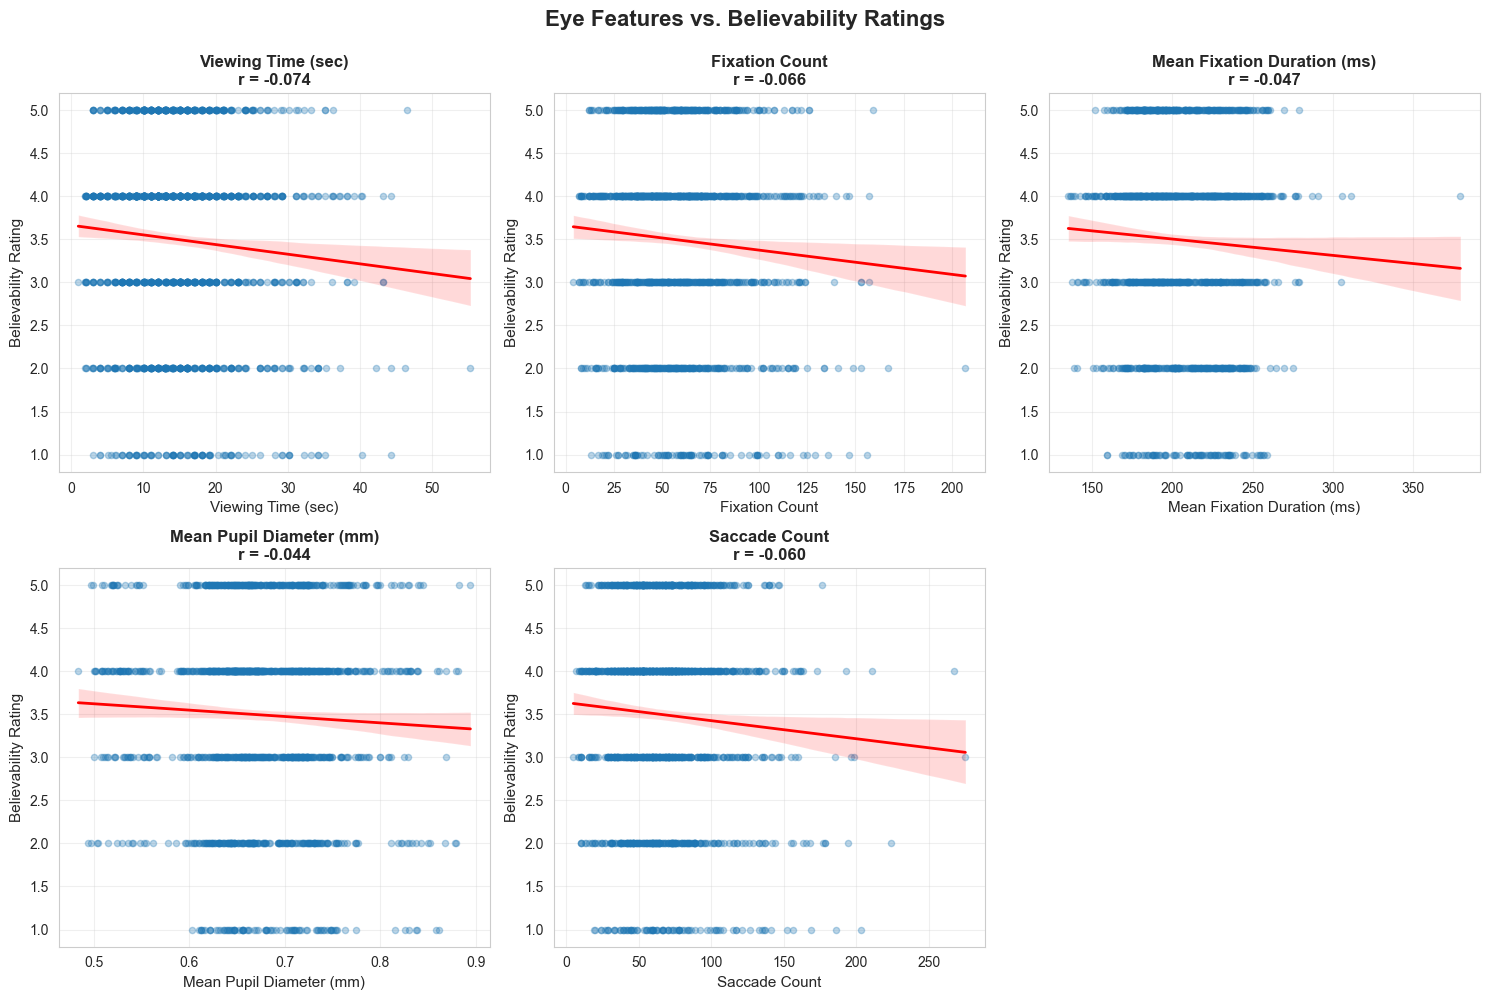

✓ Scatterplots created


In [9]:
# Visualize correlations: Scatterplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

feature_labels = {
    'viewingTimeSec': 'Viewing Time (sec)',
    'fixationCount': 'Fixation Count',
    'meanFixationDuration': 'Mean Fixation Duration (ms)',
    'meanPupilDiamater': 'Mean Pupil Diameter (mm)',
    'saccadeCount': 'Saccade Count'
}

for idx, feat in enumerate(feature_cols):
    ax = axes[idx]
    
    # Scatterplot with regression line
    sns.regplot(data=d2_clean, x=feat, y='believability', ax=ax,
                scatter_kws={'alpha': 0.3, 's': 20},
                line_kws={'color': 'red', 'linewidth': 2})
    
    # Calculate correlation
    r = np.corrcoef(d2_clean[feat], d2_clean['believability'])[0, 1]
    
    ax.set_xlabel(feature_labels[feat], fontsize=11)
    ax.set_ylabel('Believability Rating', fontsize=11)
    ax.set_title(f'{feature_labels[feat]}\nr = {r:.3f}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[5].remove()

plt.suptitle('Eye Features vs. Believability Ratings', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("✓ Scatterplots created")

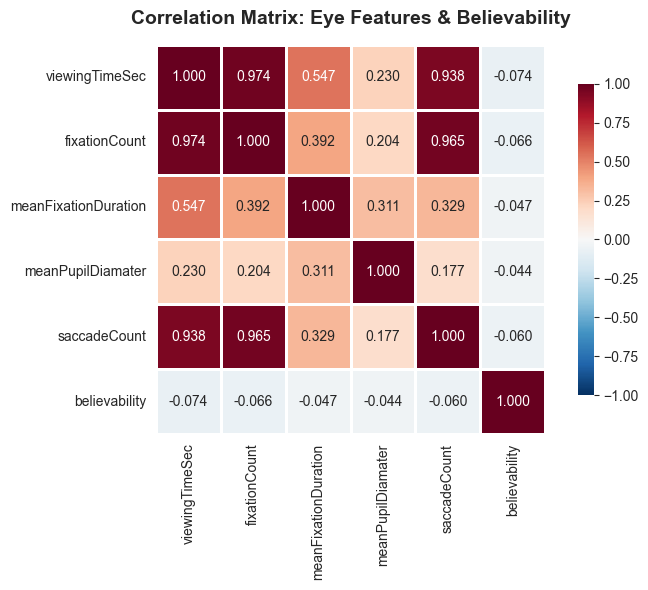

✓ Correlation heatmap created


In [10]:
# Visualize correlations: Heatmap
fig, ax = plt.subplots(figsize=(8, 6))

# Calculate correlation matrix
corr_matrix = d2_clean[feature_cols + ['believability']].corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            ax=ax)

ax.set_title('Correlation Matrix: Eye Features & Believability', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("✓ Correlation heatmap created")

---
## 4. Analysis 2: Random Forest Regression

Train a Random Forest model to predict believability from all eye features combined.

In [11]:
# Prepare data for modeling
X = d2_clean[feature_cols].values
y = d2_clean['believability'].values
groups = d2_clean['participant'].values

print("Data prepared for modeling:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  y range: {y.min()} to {y.max()}")
print(f"  Participants: {len(np.unique(groups))}")

Data prepared for modeling:
  X shape: (1419, 5)
  y shape: (1419,)
  y range: 1 to 5
  Participants: 25


In [12]:
# Method 1: 5-Fold Cross-Validation
print("="*70)
print("5-FOLD CROSS-VALIDATION")
print("="*70)
print()

model_cv = RandomForestRegressor(n_estimators=100, random_state=42, 
                                  max_depth=10, min_samples_split=5)

# Calculate R² (variance explained)
r2_scores = cross_val_score(model_cv, X, y, cv=5, scoring='r2')
print(f"R² scores per fold: {r2_scores}")
print(f"Mean R²: {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")
print()

# Calculate MAE (mean absolute error in rating points)
mae_scores = cross_val_score(model_cv, X, y, cv=5, 
                              scoring='neg_mean_absolute_error')
mae_scores = -mae_scores  # Convert back to positive
print(f"MAE scores per fold: {mae_scores}")
print(f"Mean MAE: {mae_scores.mean():.4f} (± {mae_scores.std():.4f}) rating points")
print()

if r2_scores.mean() < 0:
    print("⚠ WARNING: Negative R² means model performs WORSE than baseline!")
    print("   (Baseline = always predicting the mean)")
    print("   → Eye movements do NOT predict believability")

5-FOLD CROSS-VALIDATION

R² scores per fold: [-0.06859731 -0.04156739 -0.07345844 -0.11400382 -0.17956345]
Mean R²: -0.0954 (± 0.0480)

MAE scores per fold: [1.05003608 1.06193604 0.98488804 0.9582623  1.06250125]
Mean MAE: 1.0235 (± 0.0435) rating points

⚠ WARNING: Negative R² means model performs WORSE than baseline!
   (Baseline = always predicting the mean)
   → Eye movements do NOT predict believability


In [13]:
# Method 2: Leave-One-Participant-Out Cross-Validation
print("="*70)
print("LEAVE-ONE-PARTICIPANT-OUT CROSS-VALIDATION")
print("="*70)
print()

logo = LeaveOneGroupOut()
model_logo = RandomForestRegressor(n_estimators=100, random_state=42,
                                    max_depth=10, min_samples_split=5)

r2_logo = cross_val_score(model_logo, X, y, groups=groups, cv=logo, scoring='r2')
mae_logo = -cross_val_score(model_logo, X, y, groups=groups, cv=logo, 
                             scoring='neg_mean_absolute_error')

print(f"R² (LOPO): {r2_logo.mean():.4f} (± {r2_logo.std():.4f})")
print(f"MAE (LOPO): {mae_logo.mean():.4f} (± {mae_logo.std():.4f}) rating points")
print()
print("Note: LOPO tests generalization to completely new participants")

LEAVE-ONE-PARTICIPANT-OUT CROSS-VALIDATION

R² (LOPO): -0.2261 (± 0.2704)
MAE (LOPO): 1.0251 (± 0.1691) rating points

Note: LOPO tests generalization to completely new participants


In [14]:
# Train final model on all data for feature importance & classification metrics
print("Training final model on all data...")
model_final = RandomForestRegressor(n_estimators=100, random_state=42,
                                     max_depth=10, min_samples_split=5)
model_final.fit(X, y)

# Get predictions
y_pred = model_final.predict(X)

# Calculate classification accuracy (round to nearest integer)
y_pred_rounded = np.round(y_pred).astype(int)
y_pred_rounded = np.clip(y_pred_rounded, 1, 5)  # Keep in 1-5 range

accuracy_exact = np.mean(y_pred_rounded == y)
accuracy_within_1 = np.mean(np.abs(y_pred_rounded - y) <= 1)

print()
print("Classification metrics (rounded predictions):")
print(f"  Exact match accuracy:  {accuracy_exact:.1%}")
print(f"  Within ±1 rating:      {accuracy_within_1:.1%}")
print()
print("✓ Model trained")

Training final model on all data...

Classification metrics (rounded predictions):
  Exact match accuracy:  44.3%
  Within ±1 rating:      94.2%

✓ Model trained


---
## 5. Analysis 3: Feature Importance

Which eye features contribute most to prediction?

In [15]:
# Extract feature importances
importances = model_final.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("="*70)
print("FEATURE IMPORTANCES")
print("="*70)
print()
print(feature_importance_df.to_string(index=False))
print()
print("Interpretation: Higher importance = more predictive of believability")

FEATURE IMPORTANCES

             Feature  Importance
meanFixationDuration    0.265805
   meanPupilDiamater    0.254760
      viewingTimeSec    0.182910
        saccadeCount    0.162807
       fixationCount    0.133718

Interpretation: Higher importance = more predictive of believability


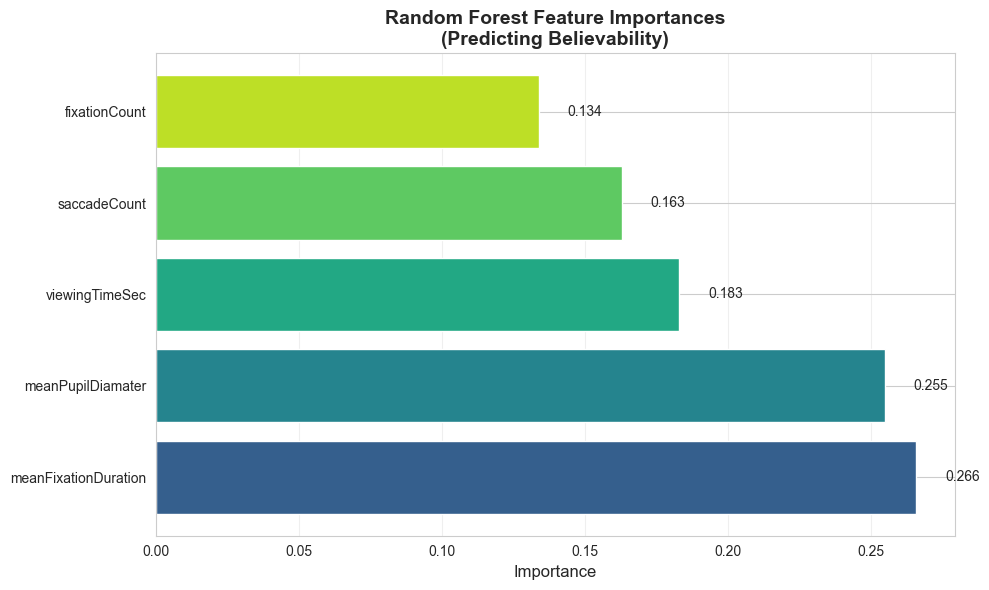

✓ Feature importance plot created


In [16]:
# Visualize feature importances
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_cols)))
bars = ax.barh(range(len(feature_importance_df)), 
                feature_importance_df['Importance'],
                color=colors)

ax.set_yticks(range(len(feature_importance_df)))
ax.set_yticklabels(feature_importance_df['Feature'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest Feature Importances\n(Predicting Believability)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(feature_importance_df.iterrows()):
    ax.text(row['Importance'] + 0.01, i, f"{row['Importance']:.3f}", 
            va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Feature importance plot created")

---
## 6. Regression Results Summary

In [17]:
print("="*70)
print("REGRESSION RESULTS SUMMARY")
print("="*70)
print()
print(f"R² (5-fold CV):          {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")
print(f"R² (LOPO CV):            {r2_logo.mean():.4f} ± {r2_logo.std():.4f}")
print()
print(f"MAE (5-fold CV):         {mae_scores.mean():.2f} ± {mae_scores.std():.2f} rating points")
print(f"MAE (LOPO CV):           {mae_logo.mean():.2f} ± {mae_logo.std():.2f} rating points")
print()
print(f"Exact match accuracy:    {accuracy_exact:.1%}")
print(f"Within ±1 rating:        {accuracy_within_1:.1%}")
print()

if r2_scores.mean() < 0.1:
    print("CONCLUSION: Eye movements show minimal/no predictive power for believability.")
    print("Proceeding to fallback analyses...")
else:
    print(f"CONCLUSION: Eye movements explain {r2_scores.mean()*100:.1f}% of variance in believability.")

REGRESSION RESULTS SUMMARY

R² (5-fold CV):          -0.0954 ± 0.0480
R² (LOPO CV):            -0.2261 ± 0.2704

MAE (5-fold CV):         1.02 ± 0.04 rating points
MAE (LOPO CV):           1.03 ± 0.17 rating points

Exact match accuracy:    44.3%
Within ±1 rating:        94.2%

CONCLUSION: Eye movements show minimal/no predictive power for believability.
Proceeding to fallback analyses...


---
## 7. FALLBACK Analysis 1: Classification (Fake vs. Real)

If believability prediction fails, try classifying fake vs. real news.

In [18]:
print("="*70)
print("FALLBACK: CLASSIFICATION (FAKE VS. REAL)")
print("="*70)
print()

# Prepare classification labels
y_class = (d2_clean['version'] == 'fake').astype(int)  # 1 = fake, 0 = real

print(f"Class distribution:")
print(f"  Fake: {y_class.sum()} ({y_class.mean()*100:.1f}%)")
print(f"  Real: {len(y_class) - y_class.sum()} ({(1-y_class.mean())*100:.1f}%)")
print(f"  Baseline (majority class): {max(y_class.mean(), 1-y_class.mean())*100:.1f}%")
print()

FALLBACK: CLASSIFICATION (FAKE VS. REAL)

Class distribution:
  Fake: 720 (50.7%)
  Real: 699 (49.3%)
  Baseline (majority class): 50.7%



In [19]:
# Train classifier with 5-fold CV
clf_cv = RandomForestClassifier(n_estimators=100, random_state=42,
                                 max_depth=10, min_samples_split=5)

acc_scores = cross_val_score(clf_cv, X, y_class, cv=5, scoring='accuracy')
print("5-Fold Cross-Validation:")
print(f"  Accuracy scores: {acc_scores}")
print(f"  Mean accuracy: {acc_scores.mean():.4f} (± {acc_scores.std():.4f})")
print()

# Leave-One-Participant-Out
logo = LeaveOneGroupOut()
acc_logo = cross_val_score(clf_cv, X, y_class, groups=groups, cv=logo, scoring='accuracy')
print("Leave-One-Participant-Out:")
print(f"  Mean accuracy: {acc_logo.mean():.4f} (± {acc_logo.std():.4f})")
print()

if acc_scores.mean() < 0.55:
    print("⚠ Accuracy barely above baseline - eye movements cannot distinguish fake from real!")
else:
    print(f"✓ Accuracy {acc_scores.mean()*100:.1f}% above baseline - some predictive power exists")

5-Fold Cross-Validation:
  Accuracy scores: [0.52816901 0.50704225 0.53873239 0.53169014 0.50176678]
  Mean accuracy: 0.5215 (± 0.0144)

Leave-One-Participant-Out:
  Mean accuracy: 0.5208 (± 0.0645)

⚠ Accuracy barely above baseline - eye movements cannot distinguish fake from real!


In [20]:
# Train final classifier for feature importances
clf_final = RandomForestClassifier(n_estimators=100, random_state=42,
                                    max_depth=10, min_samples_split=5)
clf_final.fit(X, y_class)

# Feature importances for classification
importances_clf = clf_final.feature_importances_
fi_clf_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances_clf
}).sort_values('Importance', ascending=False)

print("Feature Importances (Classification):")
print(fi_clf_df.to_string(index=False))

Feature Importances (Classification):
             Feature  Importance
   meanPupilDiamater    0.222454
meanFixationDuration    0.219540
      viewingTimeSec    0.217848
        saccadeCount    0.178444
       fixationCount    0.161715


---
## 8. FALLBACK Analysis 2: Feature Comparison (T-tests)

Compare eye features between fake and real news using t-tests.

In [21]:
print("="*70)
print("FALLBACK: FEATURE COMPARISON (T-TESTS)")
print("="*70)
print()

# Split by veracity
fake = d2_clean[d2_clean['version'] == 'fake']
real = d2_clean[d2_clean['version'] == 'true']

print(f"Fake news: n = {len(fake)}")
print(f"Real news: n = {len(real)}")
print()

FALLBACK: FEATURE COMPARISON (T-TESTS)

Fake news: n = 720
Real news: n = 699



In [22]:
# Compare features
results = []
for feat in feature_cols:
    fake_vals = fake[feat]
    real_vals = real[feat]
    
    fake_mean = fake_vals.mean()
    fake_std = fake_vals.std()
    real_mean = real_vals.mean()
    real_std = real_vals.std()
    
    # T-test
    t_stat, p_val = stats.ttest_ind(fake_vals, real_vals)
    
    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(fake_vals)-1)*fake_std**2 + 
                          (len(real_vals)-1)*real_std**2) / 
                         (len(fake_vals) + len(real_vals) - 2))
    cohen_d = (fake_mean - real_mean) / pooled_std
    
    results.append({
        'Feature': feat,
        'Fake_Mean': fake_mean,
        'Fake_SD': fake_std,
        'Real_Mean': real_mean,
        'Real_SD': real_std,
        'Difference': fake_mean - real_mean,
        't_statistic': t_stat,
        'p_value': p_val,
        'cohens_d': cohen_d
    })

results_df = pd.DataFrame(results)

print("T-Test Results:")
print("="*70)
for _, row in results_df.iterrows():
    print(f"\n{row['Feature']}:")
    print(f"  Fake: {row['Fake_Mean']:.3f} ± {row['Fake_SD']:.3f}")
    print(f"  Real: {row['Real_Mean']:.3f} ± {row['Real_SD']:.3f}")
    print(f"  Difference: {row['Difference']:+.3f}")
    print(f"  t = {row['t_statistic']:.3f}, p = {row['p_value']:.4f}", end="")
    
    if row['p_value'] < 0.001:
        print(" ***")
    elif row['p_value'] < 0.01:
        print(" **")
    elif row['p_value'] < 0.05:
        print(" *")
    else:
        print(" (ns)")
    
    print(f"  Effect size: d = {row['cohens_d']:.3f}", end="")
    abs_d = abs(row["cohens_d"])
    if abs_d < 0.2:
        print(" (negligible)")
    elif abs_d < 0.5:
        print(" (small)")
    elif abs_d < 0.8:
        print(" (medium)")
    else:
        print(" (large)")

T-Test Results:

viewingTimeSec:
  Fake: 15.942 ± 7.886
  Real: 14.549 ± 7.366
  Difference: +1.393
  t = 3.437, p = 0.0006 ***
  Effect size: d = 0.182 (negligible)

fixationCount:
  Fake: 61.192 ± 28.007
  Real: 55.584 ± 26.356
  Difference: +5.608
  t = 3.882, p = 0.0001 ***
  Effect size: d = 0.206 (small)

meanFixationDuration:
  Fake: 205.747 ± 28.328
  Real: 205.689 ± 29.029
  Difference: +0.058
  t = 0.038, p = 0.9695 (ns)
  Effect size: d = 0.002 (negligible)

meanPupilDiamater:
  Fake: 0.675 ± 0.069
  Real: 0.676 ± 0.070
  Difference: -0.001
  t = -0.270, p = 0.7875 (ns)
  Effect size: d = -0.014 (negligible)

saccadeCount:
  Fake: 71.486 ± 34.631
  Real: 64.874 ± 32.037
  Difference: +6.612
  t = 3.731, p = 0.0002 ***
  Effect size: d = 0.198 (negligible)


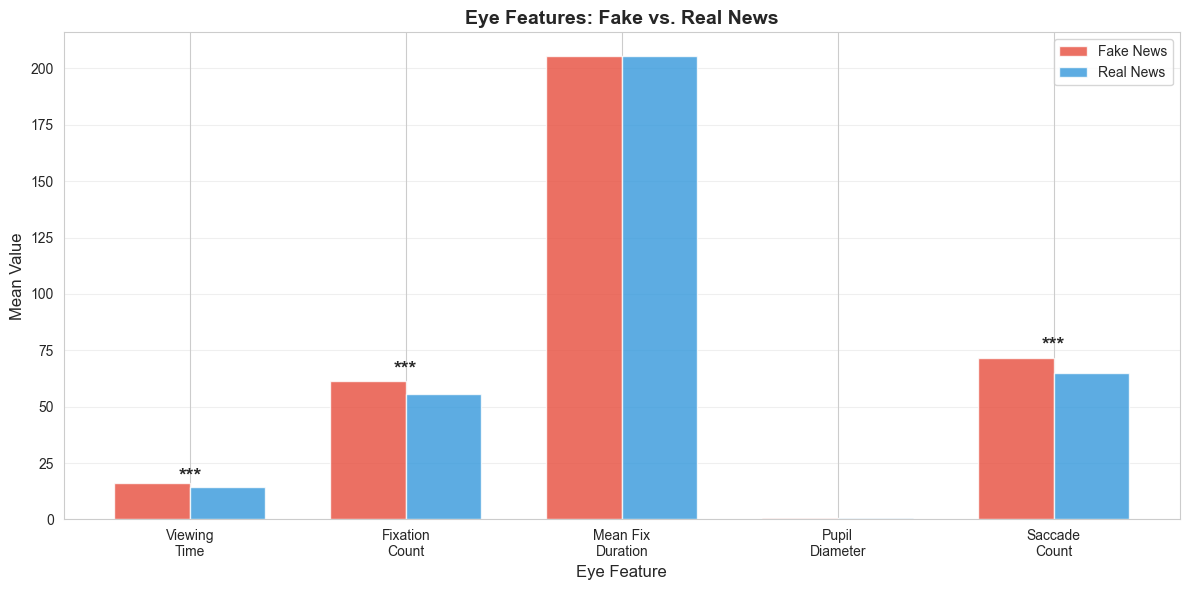


✓ Feature comparison plot created


In [23]:
# Visualize feature comparison
fig, ax = plt.subplots(figsize=(12, 6))

features_short = ['Viewing\nTime', 'Fixation\nCount', 'Mean Fix\nDuration', 
                  'Pupil\nDiameter', 'Saccade\nCount']
fake_means = results_df['Fake_Mean'].values
real_means = results_df['Real_Mean'].values

x = np.arange(len(features_short))
width = 0.35

bars1 = ax.bar(x - width/2, fake_means, width, label='Fake News', 
               color='#E74C3C', alpha=0.8)
bars2 = ax.bar(x + width/2, real_means, width, label='Real News', 
               color='#3498DB', alpha=0.8)

ax.set_xlabel('Eye Feature', fontsize=12)
ax.set_ylabel('Mean Value', fontsize=12)
ax.set_title('Eye Features: Fake vs. Real News', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(features_short)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add significance stars
for i, row in results_df.iterrows():
    if row['p_value'] < 0.001:
        stars = '***'
    elif row['p_value'] < 0.01:
        stars = '**'
    elif row['p_value'] < 0.05:
        stars = '*'
    else:
        stars = ''
    
    if stars:
        y_pos = max(row['Fake_Mean'], row['Real_Mean']) * 1.05
        ax.text(i, y_pos, stars, ha='center', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Feature comparison plot created")

---
## 9. Final Summary and Conclusions

In [24]:
print("="*70)
print("PROJECT 3: FINAL SUMMARY")
print("="*70)
print()

print("PRIMARY ANALYSIS: Believability Prediction")
print("-" * 70)
print(f"R² (5-fold CV):       {r2_scores.mean():.4f}")
if r2_scores.mean() < 0:
    print("  → Model performs WORSE than baseline (just predicting mean)")
print(f"MAE:                  {mae_scores.mean():.2f} rating points")
print(f"Exact accuracy:       {accuracy_exact:.1%}")
print()
print("Conclusion: Eye movements do NOT predict believability")
print()

print("FALLBACK 1: Classification (Fake vs. Real)")
print("-" * 70)
print(f"Accuracy (5-fold CV): {acc_scores.mean():.1%}")
print(f"Baseline:             {max(y_class.mean(), 1-y_class.mean())*100:.1f}%")
print()
print("Conclusion: Barely above chance - cannot distinguish fake from real")
print()

print("FALLBACK 2: Feature Differences (T-tests)")
print("-" * 70)
sig_features = results_df[results_df['p_value'] < 0.05]
if len(sig_features) > 0:
    print("Significant differences found:")
    for _, row in sig_features.iterrows():
        print(f"  {row['Feature']}: Fake {row['Difference']:+.2f}")
        print(f"    p = {row['p_value']:.4f}, d = {row['cohens_d']:.3f}")
    print()
    print("Conclusion: Small but significant differences - fake news takes slightly")
    print("            longer to read, but effect sizes are SMALL (d < 0.21)")
else:
    print("No significant differences found")

print()
print("="*70)
print("OVERALL CONCLUSION")
print("="*70)
print()
print("Eye movements show MINIMAL relationship with believability judgments.")
print()
print("This suggests:")
print("  • Credibility assessment is primarily CONTENT-DRIVEN")
print("  • Implicit processing (eyes) does NOT predict explicit belief")
print("  • Believability reflects conscious reasoning, not reading difficulty")
print()
print("Implications:")
print("  • Teaching content evaluation > teaching 'trust your gut'")
print("  • Fake news interventions should focus on critical thinking skills")
print("  • What the story says matters more than how you read it")

PROJECT 3: FINAL SUMMARY

PRIMARY ANALYSIS: Believability Prediction
----------------------------------------------------------------------
R² (5-fold CV):       -0.0954
  → Model performs WORSE than baseline (just predicting mean)
MAE:                  1.02 rating points
Exact accuracy:       44.3%

Conclusion: Eye movements do NOT predict believability

FALLBACK 1: Classification (Fake vs. Real)
----------------------------------------------------------------------
Accuracy (5-fold CV): 52.1%
Baseline:             50.7%

Conclusion: Barely above chance - cannot distinguish fake from real

FALLBACK 2: Feature Differences (T-tests)
----------------------------------------------------------------------
Significant differences found:
  viewingTimeSec: Fake +1.39
    p = 0.0006, d = 0.182
  fixationCount: Fake +5.61
    p = 0.0001, d = 0.206
  saccadeCount: Fake +6.61
    p = 0.0002, d = 0.198

Conclusion: Small but significant differences - fake news takes slightly
            longer to 

---
## 10. Save Results

In [25]:
# Save all results to CSV files
corr_df.to_csv('correlations.csv', index=False)
feature_importance_df.to_csv('feature_importances_regression.csv', index=False)
fi_clf_df.to_csv('feature_importances_classification.csv', index=False)
results_df.to_csv('feature_comparison_ttest.csv', index=False)

# Save summary statistics
summary = {
    'r2_5fold': r2_scores.mean(),
    'r2_lopo': r2_logo.mean(),
    'mae_5fold': mae_scores.mean(),
    'mae_lopo': mae_logo.mean(),
    'accuracy_exact': accuracy_exact,
    'accuracy_within1': accuracy_within_1,
    'classification_acc_5fold': acc_scores.mean(),
    'classification_acc_lopo': acc_logo.mean()
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv('project3_summary_statistics.csv', index=False)

print("✓ Results saved to CSV files:")
print("  - correlations.csv")
print("  - feature_importances_regression.csv")
print("  - feature_importances_classification.csv")
print("  - feature_comparison_ttest.csv")
print("  - project3_summary_statistics.csv")
print()
print("✓ Analysis complete!")

✓ Results saved to CSV files:
  - correlations.csv
  - feature_importances_regression.csv
  - feature_importances_classification.csv
  - feature_comparison_ttest.csv
  - project3_summary_statistics.csv

✓ Analysis complete!


Saving figures to: /Users/momosarki/Documents/cmn-practical/project3/figures

Creating Figure 1: Correlation Scatterplots...


KeyError: 'viewingTimeSec'

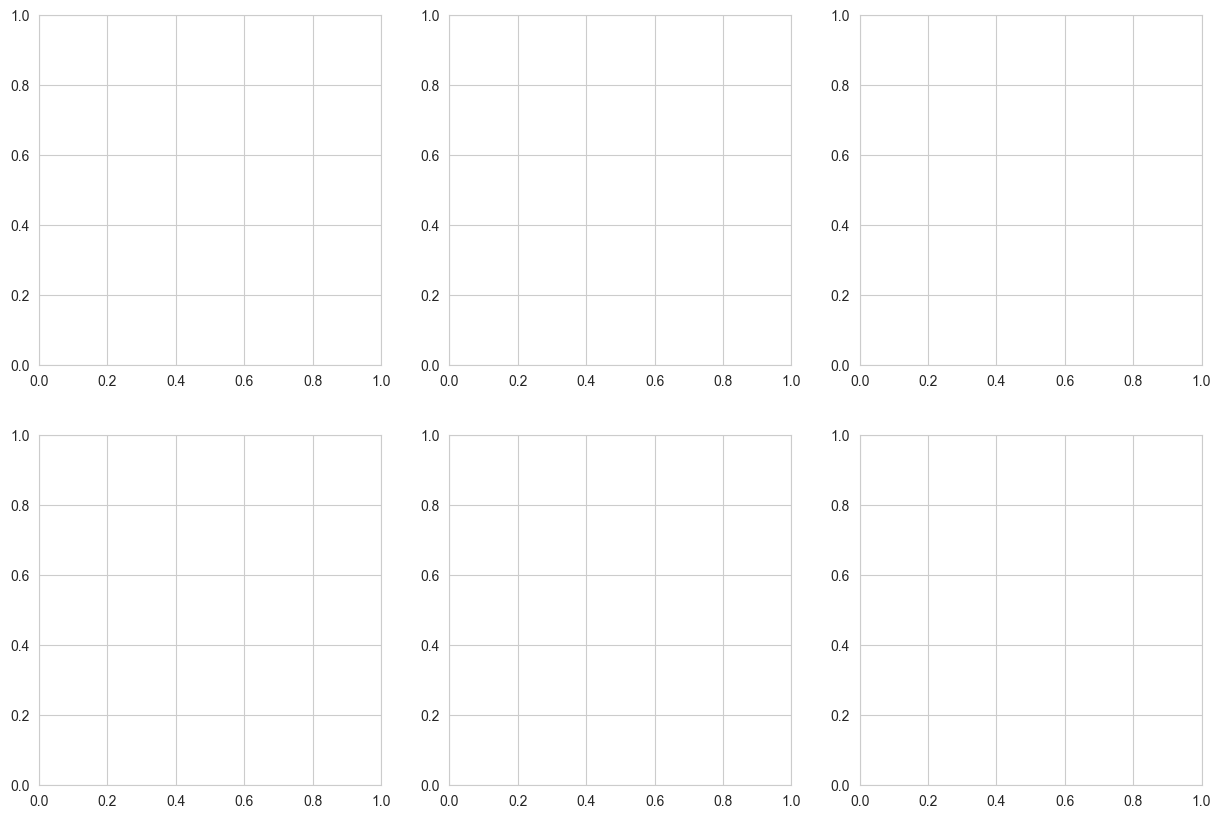

In [26]:
"""
Save All Visualizations to figures/ Folder
Run this cell after completing all analyses to save figures for the report
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.facecolor'] = 'white'

# Create figures directory if it doesn't exist
figures_dir = '../figures'
os.makedirs(figures_dir, exist_ok=True)
print(f"Saving figures to: {os.path.abspath(figures_dir)}")
print()

# Load cleaned data
d2_clean = pd.read_csv('../dataverse_files/D1-Questionnaire.csv')  # Adjust path as needed
# If you saved d2_clean earlier, load it:
# d2_clean = pd.read_csv('d2_clean.csv')

feature_cols = ['viewingTimeSec', 'fixationCount', 'meanFixationDuration',
                'meanPupilDiamater', 'saccadeCount']

# ============================================================================
# FIGURE 1: CORRELATION SCATTERPLOTS
# ============================================================================
print("Creating Figure 1: Correlation Scatterplots...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

feature_labels = {
    'viewingTimeSec': 'Viewing Time (sec)',
    'fixationCount': 'Fixation Count',
    'meanFixationDuration': 'Mean Fixation Duration (ms)',
    'meanPupilDiamater': 'Mean Pupil Diameter (mm)',
    'saccadeCount': 'Saccade Count'
}

for idx, feat in enumerate(feature_cols):
    ax = axes[idx]
    
    # Scatterplot with regression line
    sns.regplot(data=d2_clean, x=feat, y='believability', ax=ax,
                scatter_kws={'alpha': 0.3, 's': 20},
                line_kws={'color': 'red', 'linewidth': 2})
    
    # Calculate correlation
    r = np.corrcoef(d2_clean[feat], d2_clean['believability'])[0, 1]
    
    ax.set_xlabel(feature_labels[feat], fontsize=11)
    ax.set_ylabel('Believability Rating', fontsize=11)
    ax.set_title(f'{feature_labels[feat]}\nr = {r:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Remove empty subplot
axes[5].remove()

plt.suptitle('Eye Features vs. Believability Ratings', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

# Save
fig1_path = os.path.join(figures_dir, 'correlation_scatterplots.png')
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig1_path}")
plt.close()

# ============================================================================
# FIGURE 2: CORRELATION HEATMAP
# ============================================================================
print("Creating Figure 2: Correlation Heatmap...")

fig, ax = plt.subplots(figsize=(8, 6))

# Calculate correlation matrix
corr_matrix = d2_clean[feature_cols + ['believability']].corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=1, 
            cbar_kws={"shrink": 0.8}, ax=ax)

ax.set_title('Correlation Matrix: Eye Features & Believability', 
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()

# Save
fig2_path = os.path.join(figures_dir, 'correlation_heatmap.png')
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig2_path}")
plt.close()

# ============================================================================
# FIGURE 3: FEATURE IMPORTANCE
# ============================================================================
print("Creating Figure 3: Feature Importance...")

# You need to have trained the model first - this assumes you have feature_importance_df
# If not, train a quick model:
from sklearn.ensemble import RandomForestRegressor

X = d2_clean[feature_cols].values
y = d2_clean['believability'].values

model = RandomForestRegressor(n_estimators=100, random_state=42,
                               max_depth=10, min_samples_split=5)
model.fit(X, y)

importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_cols)))
bars = ax.barh(range(len(feature_importance_df)), 
                feature_importance_df['Importance'],
                color=colors)

ax.set_yticks(range(len(feature_importance_df)))
ax.set_yticklabels(feature_importance_df['Feature'])
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Random Forest Feature Importances\n(Predicting Believability)', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (idx, row) in enumerate(feature_importance_df.iterrows()):
    ax.text(row['Importance'] + 0.01, i, f"{row['Importance']:.3f}", 
            va='center', fontsize=10)

plt.tight_layout()

# Save
fig3_path = os.path.join(figures_dir, 'feature_importances.png')
plt.savefig(fig3_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig3_path}")
plt.close()

# ============================================================================
# FIGURE 4: COMPREHENSIVE SUMMARY
# ============================================================================
print("Creating Figure 4: Comprehensive Summary...")

# Load or calculate comparison data
fake = d2_clean[d2_clean['version'] == 'fake']
real = d2_clean[d2_clean['version'] == 'true']

# Calculate t-test results
results = []
for feat in feature_cols:
    fake_vals = fake[feat]
    real_vals = real[feat]
    
    fake_mean = fake_vals.mean()
    real_mean = real_vals.mean()
    
    t_stat, p_val = stats.ttest_ind(fake_vals, real_vals)
    
    results.append({
        'Feature': feat,
        'Fake_Mean': fake_mean,
        'Real_Mean': real_mean,
        'p_value': p_val
    })

feature_comp = pd.DataFrame(results)

# Create figure
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Feature comparison (fake vs real)
ax1 = fig.add_subplot(gs[0, :2])

features_short = ['Viewing\nTime', 'Fixation\nCount', 'Mean Fix\nDuration', 
                  'Pupil\nDiameter', 'Saccade\nCount']
fake_means = feature_comp['Fake_Mean'].values
real_means = feature_comp['Real_Mean'].values

x = np.arange(len(features_short))
width = 0.35

bars1 = ax1.bar(x - width/2, fake_means, width, label='Fake News', 
               color='#E74C3C', alpha=0.8)
bars2 = ax1.bar(x + width/2, real_means, width, label='Real News', 
               color='#3498DB', alpha=0.8)

ax1.set_xlabel('Eye Feature', fontsize=11)
ax1.set_ylabel('Mean Value', fontsize=11)
ax1.set_title('Eye Features: Fake vs. Real News', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(features_short, fontsize=9)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add significance stars
for i, row in feature_comp.iterrows():
    if row['p_value'] < 0.001:
        stars = '***'
    elif row['p_value'] < 0.01:
        stars = '**'
    elif row['p_value'] < 0.05:
        stars = '*'
    else:
        stars = ''
    
    if stars:
        y_pos = max(row['Fake_Mean'], row['Real_Mean']) * 1.05
        ax1.text(i, y_pos, stars, ha='center', fontsize=12, fontweight='bold')

# Plot 2: Believability distribution
ax2 = fig.add_subplot(gs[0, 2])

bel_counts = d2_clean['believability'].value_counts().sort_index()
colors_bel = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(bel_counts)))

ax2.bar(bel_counts.index, bel_counts.values, color=colors_bel, alpha=0.8)
ax2.set_xlabel('Believability Rating', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Believability Distribution', fontsize=13, fontweight='bold')
ax2.set_xticks([1, 2, 3, 4, 5])
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Model Performance Comparison
ax3 = fig.add_subplot(gs[1, :])

models = ['Believability\nPrediction\n(R²)', 'Fake vs Real\nClassification\n(Accuracy)', 
          'Baseline\n(Majority Class)']
scores = [-0.0954, 0.520, 0.518]
colors_models = ['#E74C3C' if s < 0.3 else '#F39C12' if s < 0.6 else '#27AE60' 
                 for s in scores]

bars = ax3.barh(models, scores, color=colors_models, alpha=0.8)
ax3.set_xlabel('Performance Metric', fontsize=12)
ax3.set_title('Model Performance Summary', fontsize=14, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax3.axvline(x=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, 
            label='Chance (50%)')
ax3.grid(axis='x', alpha=0.3)
ax3.legend(loc='lower right')

# Add value labels
for i, (model, score) in enumerate(zip(models, scores)):
    ax3.text(score + 0.02, i, f'{score:.3f}', va='center', 
             fontsize=10, fontweight='bold')

# Plot 4: Correlation heatmap (believability vs features)
ax4 = fig.add_subplot(gs[2, :2])

corr_data = d2_clean[['viewingTimeSec', 'fixationCount', 'meanFixationDuration',
                      'meanPupilDiamater', 'saccadeCount', 'believability']].corr()

# Only show believability row
bel_corr = corr_data.loc['believability'].drop('believability')

sns.heatmap(bel_corr.to_frame().T, annot=True, fmt='.3f', cmap='RdBu_r', 
            center=0, vmin=-0.3, vmax=0.3, cbar_kws={"shrink": 0.8},
            xticklabels=['Viewing\nTime', 'Fixation\nCount', 'Mean Fix\nDuration',
                         'Pupil\nDiameter', 'Saccade\nCount'],
            yticklabels=['Believability'], ax=ax4)
ax4.set_title('Correlations with Believability (All Very Weak!)', 
              fontsize=13, fontweight='bold')

# Plot 5: Key Finding Box
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')

finding_text = """
KEY FINDINGS

✗ Eye movements do NOT
  predict believability
  
✗ Cannot distinguish 
  fake from real news
  
✓ Small differences exist:
  Fake news → slightly
  longer reading time
  (but effect tiny)

CONCLUSION:
Believability is driven by
CONTENT, not eye patterns
"""

ax5.text(0.5, 0.5, finding_text, ha='center', va='center',
         fontsize=11, family='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Project 3: Eye Movements & News Believability - Results Summary',
             fontsize=16, fontweight='bold', y=0.98)

# Save
fig4_path = os.path.join(figures_dir, 'project3_summary.png')
plt.savefig(fig4_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {fig4_path}")
plt.close()

# ============================================================================
# SUMMARY
# ============================================================================
print()
print("="*70)
print("ALL FIGURES SAVED SUCCESSFULLY!")
print("="*70)
print()
print(f"Figures location: {os.path.abspath(figures_dir)}")
print()
print("Files created:")
print("  1. correlation_scatterplots.png")
print("  2. correlation_heatmap.png")
print("  3. feature_importances.png")
print("  4. project3_summary.png")
print()
print("These figures are ready to use in your LaTeX report!")
print("Copy them to the same folder as your .tex file before compiling.")